# 02b — UC2 FedAvg on the new (label-skew) partitions

Trains FedAvg across the α sweep on the **new** partitions from notebook 00,
for **both** evaluation designs:

- **Option A — client-local** (`new_partitions/`): each client tested on its own
  load regime. Heterogeneity shows up in **per-client MAE spread**.
- **Option B — global pool** (`new_partitions_global/`): every client tested on
  the same 3000-sample pool. Measures the **global objective**; read it as the
  **gap to Centralized**, not the raw level.

Switch designs with `PARTITION_VARIANT` in the config cell and re-run.
Results are written to `results/newpart/` (Option A) or `results/newpart_global/`
(Option B), so nothing overwrites your original AP-ID results.

> **Heads-up from the notebook-00 data:** on this dataset the heterogeneity is
> dominated by **quantity skew** (per-user sample-count Gini 0.55 → 0.06 across α)
> while **label skew is mild** (y-mean Gini ≈ 0.03–0.07). Expect modest movement
> in the *global mean* MAE across α and a clearer signal in the *per-client spread*.


In [1]:
import sys, os
sys.path.append("..")
import UC2Utils as uc2
sys.path.insert(0, uc2.LIB_DIR)

import numpy as np
import matplotlib.pyplot as plt
import pickle, json
import torch

print(f"Device: {uc2.DEFAULT_CONFIG['device']}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0),
          f"| free {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB")

Device: cuda:0
NVIDIA GeForce RTX 3050 Ti Laptop GPU | free 3.2 GB


## Configuration

In [2]:
ALPHAS = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
MODEL  = "lstm"

# Which evaluation design to run:
#   "client_local" -> new_partitions/        (Option A)
#   "global"       -> new_partitions_global/ (Option B)
PARTITION_VARIANT = "client_local"

# First run on a given variant: set True so it TRAINS instead of loading old pkls.
RETRAIN = False

OVERRIDES = dict(
    num_glob_iters=300,
    local_epochs=20,
    num_users=20,
    early_stopping_patience=25,
    batch_size=32,
)

## Partition wiring

Generalises the toggle from notebook 02 to pick the partition **variant** and to
route results to a per-variant results folder. `run_experiment` is otherwise
unchanged — only `dataset_path` and `result_path` are redirected.

In [3]:
# config: folder names must match what notebook 00 wrote
VARIANT_SUBDIR = {"client_local": "new_partitions",
                  "global":       "new_partitions_global"}
VARIANT_RESULTS = {"client_local": "newpart",
                   "global":       "newpart_global"}
assert PARTITION_VARIANT in VARIANT_SUBDIR, PARTITION_VARIANT

_NP_LOOKBACK = uc2.DEFAULT_CONFIG["lookback"]   # 60
_NP_STEPS    = uc2.DEFAULT_CONFIG["steps"]      # 1
_NP_SUBDIR   = VARIANT_SUBDIR[PARTITION_VARIANT]
_NP_RESULTS  = VARIANT_RESULTS[PARTITION_VARIANT]

# keep handles to the originals so we can toggle / restore
_orig_make_args     = uc2.make_args
_orig_result_exists = uc2.result_exists
_orig_load_result   = uc2.load_result

_NEWPART_ON = {"flag": False}

def _newpart_dataset_path():
    return os.path.join(uc2.DATA_PART, _NP_SUBDIR,
                        f"lookback_{_NP_LOOKBACK}", f"steps_{_NP_STEPS}")

def _redirect_result_path(result_path, algorithm, alpha, model):
    base = os.path.join(uc2.RESULTS, _NP_RESULTS)
    if result_path is None:
        return os.path.join(base, algorithm.lower(), f"alpha_{alpha}", model, "rep_0")
    rel = os.path.relpath(os.path.abspath(result_path), os.path.abspath(uc2.RESULTS))
    return os.path.join(base, rel)

def _patched_make_args(algorithm, alpha, result_path=None, **overrides):
    args = _orig_make_args(algorithm, alpha, result_path=result_path, **overrides)
    if _NEWPART_ON["flag"]:
        args.dataset_path = _newpart_dataset_path()
        model = {**uc2.DEFAULT_CONFIG, **overrides}["model"]
        new_rp = _redirect_result_path(result_path, algorithm, alpha, model)
        new_rp = os.path.relpath(new_rp)          # lib dislikes spaces in abs paths
        os.makedirs(new_rp, exist_ok=True)
        args.result_path = new_rp
    return args

def _patched_result_exists(algorithm, alpha, model="lstm"):
    if _NEWPART_ON["flag"]:
        p = os.path.join(uc2.RESULTS, _NP_RESULTS, algorithm.lower(),
                         f"alpha_{alpha}", model, "rep_0", "full_results.pkl")
        return os.path.exists(p)
    return _orig_result_exists(algorithm, alpha, model)

def _patched_load_result(algorithm, alpha, model="lstm"):
    if _NEWPART_ON["flag"]:
        p = os.path.join(uc2.RESULTS, _NP_RESULTS, algorithm.lower(),
                         f"alpha_{alpha}", model, "rep_0", "full_results.pkl")
        with open(p, "rb") as f:
            return pickle.load(f)
    return _orig_load_result(algorithm, alpha, model)

def use_new_partitions(on=True):
    """Toggle the selected new-partition variant for subsequent run_experiment calls."""
    _NEWPART_ON["flag"] = bool(on)
    uc2.make_args     = _patched_make_args     if on else _orig_make_args
    uc2.result_exists = _patched_result_exists if on else _orig_result_exists
    uc2.load_result   = _patched_load_result   if on else _orig_load_result
    state = f"NEW [{PARTITION_VARIANT}]" if on else "ORIGINAL AP-ID"
    print(f"[wiring] partitions = {state}")
    if on:
        dp = _newpart_dataset_path()
        print(f"[wiring] dataset_path -> {dp}")
        print(f"[wiring] results      -> {os.path.join(uc2.RESULTS, _NP_RESULTS, '...')}")
        miss = [a for a in ALPHAS if not os.path.exists(
            os.path.join(dp, f"u{uc2.DEFAULT_CONFIG['n_users']}-alpha{a}-ratio1",
                         "train", "train.pt"))]
        if miss:
            print(f"[wiring] !! MISSING partitions for alpha={miss} -- "
                  f"run notebook 00 generation for variant '{PARTITION_VARIANT}' first!")

use_new_partitions(True)

[wiring] partitions = NEW [client_local]
[wiring] dataset_path -> /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/data/partitions/new_partitions/lookback_60/steps_1
[wiring] results      -> /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/results/newpart/...


In [4]:
# --- VERIFY: client-local partition wired, clients get distinct test sets ---
import torch
_args = uc2.make_args("FedAvg", ALPHAS[0], **OVERRIDES)
print("dataset_path =", _args.dataset_path)
assert "new_partitions" in _args.dataset_path and "global" not in _args.dataset_path, \
    "WIRING OFF: dataset_path is not the client-local new_partitions root."
_server = uc2.create_server(_args)
print(f"\n{'client':>8}{'test n':>10}{'target mean':>14}")
means = []
for c in _server.users[:5]:
    xb, yb = next(iter(c.testloaderfull))
    means.append(round(float(yb.float().mean()), 4))
    print(f"{str(c.id):>8}{c.test_samples:>10}{yb.float().mean():>14.4f}")
assert len(set(means)) > 1, "Clients have identical test means -> still shared pool."
print("\n[OK] Distinct per-client test sets. Client-local wiring confirmed.")

dataset_path = /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/data/partitions/new_partitions/lookback_60/steps_1
Creating model for flags-regression
Network configs: ['LSTM-480', 'F']


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Users in total: 20
Number of users / total users: 20  /  20
Finished creating FedAvg server.

  client    test n   target mean
 f_00000       176        1.5138
 f_00001      1069        1.6877
 f_00002      1602        1.8596
 f_00003       697        1.6700
 f_00004       176        1.5140

[OK] Distinct per-client test sets. Client-local wiring confirmed.


## Train FedAvg for each α

On the **first** run of a variant keep `RETRAIN=True` so it trains rather than
loading stale pickles. Subsequent runs can set `RETRAIN=False` to just reload.

In [5]:
results_fedavg = {}

for alpha in ALPHAS:
    print(f"\n{'='*60}\n  FedAvg [{PARTITION_VARIANT}] — α={alpha}\n{'='*60}")
    if not RETRAIN and uc2.result_exists("FedAvg", alpha):
        print("  [done] loading cached result.")
        results_fedavg[alpha] = uc2.load_result("FedAvg", alpha)
        continue
    try:
        server, result = uc2.run_experiment(algorithm="FedAvg", alpha=alpha, **OVERRIDES)
        results_fedavg[alpha] = result
        glob = result["metrics"]["glob_test_metric"]
        if glob:
            bi = int(np.argmin([m.get("unscaled_mae", float("inf")) for m in glob]))
            b = glob[bi]
            print(f"  best round {bi}: MAE(unscaled)={b.get('unscaled_mae', float('nan')):.4f} "
                  f"MAPE={b.get('unscaled_mape', float('nan')):.4f}")
        pu = result.get("per_user", {}).get("metrics", {}).get("unscaled_mae", [])
        if pu:
            print(f"  per-user MAE: mean={np.mean(pu):.3f} std={np.std(pu):.3f} "
                  f"CV={np.std(pu)/np.mean(pu):.3f}")
    except Exception as e:
        import traceback; traceback.print_exc()
        print(f"  [ERROR] {e}")


  FedAvg [client_local] — α=0.01
  [done] loading cached result.

  FedAvg [client_local] — α=0.1
  [done] loading cached result.

  FedAvg [client_local] — α=0.5
  [done] loading cached result.

  FedAvg [client_local] — α=1.0
  [done] loading cached result.

  FedAvg [client_local] — α=5.0
  [done] loading cached result.

  FedAvg [client_local] — α=10.0
  [done] loading cached result.


## Training convergence per α

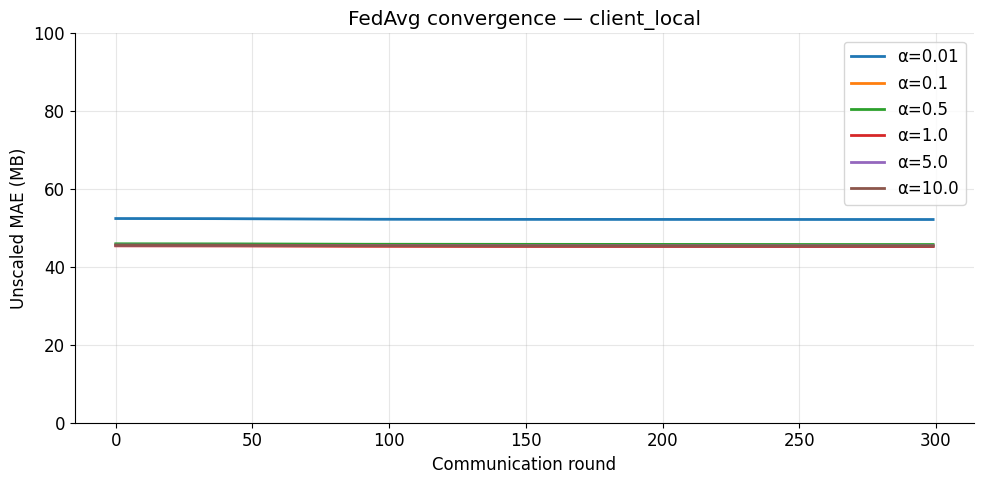

In [6]:
uc2.setup_plot_style()
fig, ax = plt.subplots(figsize=(10, 5))
for alpha, r in sorted(results_fedavg.items()):
    maes = [m.get("unscaled_mae") for m in r["metrics"].get("glob_test_metric", [])]
    ax.plot(maes, label=f"α={alpha}", lw=2)
ax.set_ylim(0, 100)
ax.set_xlabel("Communication round"); ax.set_ylabel("Unscaled MAE (MB)")
ax.set_title(f"FedAvg convergence — {PARTITION_VARIANT}")
ax.legend(); plt.tight_layout(); plt.show()

## Per-client MAE distribution by α  ← the heterogeneity signal

Under **client-local** evaluation this is where heterogeneity surfaces: at low α,
clients trained on narrow regimes (and on very different sample counts) should
show a **wider spread** of per-client MAE. Under the **global** pool every client
is tested identically, so this spread reflects only model differences.

/tmp/ipykernel_928/3800765013.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(a) for a in avail], showmeans=True,


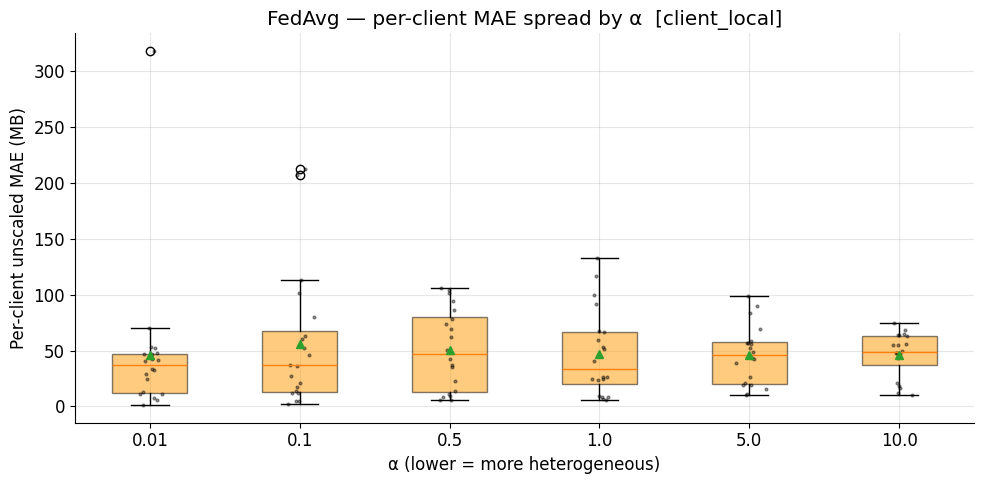

α           median      mean       std      CV   max/med    n
0.01        36.892    46.330    65.007   1.403      8.62   20
0.1         36.681    56.176    59.795   1.064      5.79   20
0.5         46.646    50.898    35.600   0.699      2.28   20
1.0         33.722    47.193    37.467   0.794      3.93   20
5.0         45.923    45.910    25.677   0.559      2.16   20
10.0        48.657    46.113    19.466   0.422      1.54   20


In [7]:
pu_by_alpha = {a: r.get("per_user", {}).get("metrics", {}).get("unscaled_mae", [])
               for a, r in results_fedavg.items()}
avail = [a for a in ALPHAS if pu_by_alpha.get(a)]

if avail:
    fig, ax = plt.subplots(figsize=(10, 5))
    data = [np.asarray(pu_by_alpha[a], float) for a in avail]
    bp = ax.boxplot(data, labels=[str(a) for a in avail], showmeans=True,
                    patch_artist=True)
    for box in bp["boxes"]:
        box.set(facecolor=uc2.COLORS["FedAvg"], alpha=0.5)
    # overlay raw points (jittered) so small-N alphas are honest
    for i, d in enumerate(data, start=1):
        x = np.random.normal(i, 0.04, size=len(d))
        ax.plot(x, d, ".", color="k", alpha=0.4, ms=4)
    ax.set_xlabel("α (lower = more heterogeneous)")
    ax.set_ylabel("Per-client unscaled MAE (MB)")
    ax.set_title(f"FedAvg — per-client MAE spread by α  [{PARTITION_VARIANT}]")
    plt.tight_layout(); plt.show()

    print(f"{'α':<8}{'median':>10}{'mean':>10}{'std':>10}{'CV':>8}{'max/med':>10}{'n':>5}")
    for a in avail:
        d = np.asarray(pu_by_alpha[a], float)
        med = np.median(d)
        print(f"{a:<8}{med:>10.3f}{d.mean():>10.3f}{d.std():>10.3f}"
              f"{d.std()/d.mean():>8.3f}{(d.max()/med if med else float('nan')):>10.2f}{len(d):>5}")
else:
    print("No per-user metrics found — run the training cell first.")

## Global metric vs α

In [8]:
def best_mae(r):
    maes = [m.get("unscaled_mae", float("inf")) for m in r["metrics"]["glob_test_metric"]]
    return min(maes) if maes else float("nan")

print(f"{'α':<8}{'best MAE':>12}{'last MAE':>12}{'best round':>12}{'per-client σ':>14}")
for a in sorted(results_fedavg):
    r = results_fedavg[a]
    maes = [m.get("unscaled_mae", float("inf")) for m in r["metrics"]["glob_test_metric"]]
    pu = pu_by_alpha.get(a, [])
    print(f"{a:<8}{min(maes):>12.4f}{maes[-1]:>12.4f}{int(np.argmin(maes)):>12}"
          f"{(np.std(pu) if pu else 0):>14.4f}")

α           best MAE    last MAE  best round  per-client σ
0.01         52.1882     52.1882         299       65.0073
0.1          45.4496     45.4496         298       59.7946
0.5          45.7634     45.7634         299       35.6000
1.0          45.2325     45.2325         299       37.4674
5.0          45.4309     45.4309         299       25.6770
10.0         45.3942     45.3943         297       19.4665


## Gap to Centralized  (run after notebook 01b on the SAME variant)

The honest α-sensitivity readout: `MAE(FedAvg, α) − MAE(Centralized, α)`. Centralized
is the α-independent ceiling. If the gap widens at low α, FedAvg is genuinely hurt
by heterogeneity even when its raw MAE looks flat.

Requires Centralized results under the SAME variant's results folder
(`results/<newpart|newpart_global>/centralized/...`). If absent, this cell just
skips the gap and shows FedAvg alone.

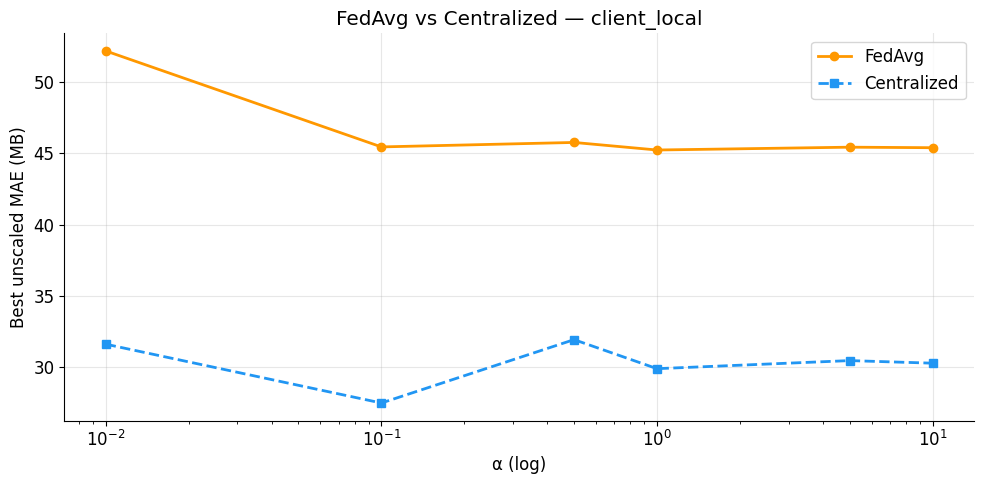

α           FedAvg   Central       gap    gap %
0.01        52.188    31.599    20.589    65.2%
0.1         45.450    27.468    17.981    65.5%
0.5         45.763    31.918    13.845    43.4%
1.0         45.233    29.879    15.353    51.4%
5.0         45.431    30.447    14.984    49.2%
10.0        45.394    30.265    15.129    50.0%


In [9]:
def _load_variant_result(algorithm, alpha):
    p = os.path.join(uc2.RESULTS, _NP_RESULTS, algorithm.lower(),
                     f"alpha_{alpha}", MODEL, "rep_0", "full_results.pkl")
    if not os.path.exists(p):
        return None
    with open(p, "rb") as f:
        return pickle.load(f)

cent = {a: _load_variant_result("Centralized", a) for a in ALPHAS}
have_cent = any(v is not None for v in cent.values())

fa_mae  = {a: best_mae(results_fedavg[a]) for a in results_fedavg}
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(fa_mae), [fa_mae[a] for a in fa_mae], "o-",
        color=uc2.COLORS["FedAvg"], lw=2, label="FedAvg")
if have_cent:
    cm = {a: best_mae(cent[a]) for a in cent if cent[a]}
    ax.plot(list(cm), [cm[a] for a in cm], "s--",
            color=uc2.COLORS["Centralized"], lw=2, label="Centralized")
ax.set_xscale("log"); ax.set_xlabel("α (log)"); ax.set_ylabel("Best unscaled MAE (MB)")
ax.set_title(f"FedAvg vs Centralized — {PARTITION_VARIANT}")
ax.legend(); plt.tight_layout(); plt.show()

if have_cent:
    print(f"{'α':<8}{'FedAvg':>10}{'Central':>10}{'gap':>10}{'gap %':>9}")
    for a in sorted(fa_mae):
        if cent.get(a):
            c = best_mae(cent[a]); g = fa_mae[a] - c
            print(f"{a:<8}{fa_mae[a]:>10.3f}{c:>10.3f}{g:>10.3f}"
                  f"{(100*g/c if c else float('nan')):>8.1f}%")
else:
    print("[info] No Centralized results for this variant yet — "
          "run notebook 01 retrained on the same PARTITION_VARIANT, then re-run this cell.")

## Communication cost

In [10]:
for a, r in sorted(results_fedavg.items()):
    n = r["n_rounds"]
    print(f"α={a}: {n} rounds → {uc2.comm_cost_fedavg(n, n_users_per_round=OVERRIDES['num_users']):.1f} MB")

α=0.01: 300 rounds → 43597.2 MB
α=0.1: 300 rounds → 43597.2 MB
α=0.5: 300 rounds → 43597.2 MB
α=1.0: 300 rounds → 43597.2 MB
α=5.0: 300 rounds → 43597.2 MB
α=10.0: 300 rounds → 43597.2 MB


## Notes

- **First run per variant:** `RETRAIN=True`. Flip `PARTITION_VARIANT` to `"global"`
  and re-run the whole notebook to produce the Option-B results.
- **Baseline:** retrain Centralized (notebook 01) under the *same* variant so the
  gap-to-Centralized cell has matching test sets. Centralized's pooled model is
  α-invariant, so this is a cheap re-evaluation, not a real retrain.
- **Reading the results on this dataset:** quantity skew is the dominant
  heterogeneity axis here (label skew is mild), so the per-client spread plot and
  the gap-to-Centralized are more informative than the global-mean MAE curve.


## FedAvg-partial ablation — head-only sharing, no generator

Isolates the **generator's contribution** to the FedGen-partial result:

| method | shared per round | generator |
|---|---|---|
| `fedavg` | full model (3.63 MB) | — |
| **`fedavg-partial`** (this cell) | head only, `decode_fc2` (33 params) | — |
| `fedgen-partial` | head only | ✓ |

If `fedavg-partial` stalls everywhere while `fedgen-partial` tracks Centralized,
the UC2 gain is attributable to the generator, not the sharing scheme (the
opposite of UC1, where partial *aggregation* does most of the work — §4.3.3).

Single seed (`rep_0`), identical protocol/`OVERRIDES` to every other newpart run.
Idempotent: alphas with existing results (e.g. α=0.01) are skipped — set
`RETRAIN_PARTIAL=True` to force. Requires the wiring cell above
(`use_new_partitions(True)`) to have run. Results →
`results/newpart/fedavg-partial/alpha_<a>/lstm/rep_0/`, picked up automatically
by `uc2_honest_table.py` and notebook 04. Caption as single-seed in the thesis.

In [11]:
# ── FedAvg-partial ablation: head-only sharing (decode_fc2, 33 params), NO generator ──
RETRAIN_PARTIAL = True   # False -> skip alphas that already have results (idempotent)

assert _NEWPART_ON["flag"], "Run the wiring cell (use_new_partitions(True)) first."

ALPHAS = [0.01]

results_fedavg_partial = {}
for alpha in ALPHAS:
    print(f"\n{'='*60}\n  FedAvg-partial [{PARTITION_VARIANT}] — α={alpha}\n{'='*60}")
    if not RETRAIN_PARTIAL and uc2.result_exists("FedAvg-partial", alpha):
        print("  [done] result exists — loading.")
        results_fedavg_partial[alpha] = uc2.load_result("FedAvg-partial", alpha)
        continue
    try:
        server, result = uc2.run_experiment(algorithm="FedAvg-partial",
                                            alpha=alpha, **OVERRIDES)
        results_fedavg_partial[alpha] = result
    except Exception as e:
        import traceback; traceback.print_exc()
        print(f"  [ERROR] {e}")

# summary on SCALED metrics (the honest ones — see uc2_honest_table.py)
print(f"\n{'α':<8}{'rounds':>7}{'first MAE':>11}{'best MAE':>10}{'last MAE':>10}"
      f"{'best MSE':>10}{'last MSE':>10}")
for a in sorted(results_fedavg_partial):
    gm = results_fedavg_partial[a]["metrics"].get("glob_test_metric", [])
    if not gm:
        continue
    mae = [m["mae"] for m in gm]
    mse = [m["mse"] for m in gm]
    print(f"{a:<8}{len(gm):>7}{mae[0]:>11.4f}{min(mae):>10.4f}{mae[-1]:>10.4f}"
          f"{min(mse):>10.4f}{mse[-1]:>10.4f}")
print("\nNB: read this ablation on scaled MAE (the trained L1 objective); like full")
print("FedAvg, best-MSE is typically the round-0 untrained init (honest-table caveat).")

# refresh uc2_results.csv so the new rows appear in 04_UC2_Results_Reframed
import importlib, uc2_honest_table as U
importlib.reload(U)
df_h = U.build_dataframe()
print('\nCSV ->', U.write_csv(df=df_h))
display(df_h[(df_h.method == 'fedavg-partial') & (df_h.protocol == 'client_local')])


  FedAvg-partial [client_local] — α=0.01
Creating model for flags-regression
Network configs: ['LSTM-480', 'F']


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Users in total: 20
Number of users / total users: 20  /  20
Finished creating FedAvg server.

Training FedAvg-partial | α=0.01 | model=lstm



-------------Round number:  0  -------------


All users are selected
Average Global Test Metrics: mse = 0.1564, mae = 0.3760, mape = 0.2763, unscaled_mse = 22776.9920, unscaled_mae = 52.4389, unscaled_mape = 181698825.8461,  Loss = 0.3760.
The model is saved!


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/users/useravg.py:43: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  self.lr_scheduler.step(glob_iter)




-------------Round number:  1  -------------


All users are selected
Average Global Test Metrics: mse = 0.1504, mae = 0.3667, mape = 0.2710, unscaled_mse = 22776.9877, unscaled_mae = 52.4389, unscaled_mape = 174162971.5852,  Loss = 0.3667.
The model is saved!


...

/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/users/useravg.py:43: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  self.lr_scheduler.step(glob_iter)




-------------Round number:  299  -------------


All users are selected
Average Global Test Metrics: mse = 0.0600, mae = 0.0952, mape = 0.0801, unscaled_mse = 11897.2123, unscaled_mae = 31.6976, unscaled_mape = 10423407112211.7090,  Loss = 0.0952.
The model is saved!


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/users/useravg.py:43: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  self.lr_scheduler.step(glob_iter)



Training completed in 2337.2s
[✓] Results saved to ../results/newpart/fedavg-partial/alpha_0.01/lstm/rep_0/full_results.pkl

α        rounds  first MAE  best MAE  last MAE  best MSE  last MSE
0.01        300     0.3760    0.0952    0.0952    0.0594    0.0600

NB: read this ablation on scaled MAE (the trained L1 objective); like full
FedAvg, best-MSE is typically the round-0 untrained init (honest-table caveat).

CSV -> /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/uc2_results.csv


,protocol,method,alpha,n_reps,best_mse,best_mse_std,last_mse,best_mae,last_mae,mse_improves,diverges
12,client_local,fedavg-partial,0.01,1,0.0594,0.0,0.0600,0.0952,0.0952,True,False
13,client_local,fedavg-partial,0.10,1,0.0952,0.0,0.1003,0.1481,0.1481,True,False
14,client_local,fedavg-partial,0.50,1,0.1506,0.0,0.1561,0.2628,0.2628,True,False
15,client_local,fedavg-partial,1.00,1,0.1367,0.0,0.1441,0.2243,0.2243,True,False
16,client_local,fedavg-partial,5.00,1,0.1704,0.0,0.1871,0.3259,0.3259,True,False
17,client_local,fedavg-partial,10.00,1,0.1715,0.0,0.1962,0.3339,0.3339,True,False
